###Env to use: birdnet

In [5]:
import librosa
from skimage import feature
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import signal
import soundfile as sf
import os
from pathlib import Path
from sklearn.metrics import average_precision_score


In [6]:
from datetime import datetime

In [7]:
df_combined = pd.read_csv("df_combined_testcase3.csv")
df_combined.head(2)

,selec,filename,recording.id,target,fold
0,5098,5098_0,15646,0,4
1,8019,NaN,15629,1,0


In [8]:
df_combined.loc[df_combined["target"] == 1, "filename"] = (
    df_combined.loc[df_combined["target"] == 1, "selec"].astype(str)
)

Predict for positive segments first

In [9]:
# np.save('holderried_predictions.npy', predictions)
preds = np.load('holderried_predictions_selections.npy', allow_pickle=True)
preds_pos = preds.item()

In [10]:
df_pos = pd.DataFrame(preds_pos.items(),columns=["filename", "prediction"])

In [11]:
len(df_pos)

2410

In [12]:
# Create selec from filename
df_pos["selec"] = (
    df_pos["filename"]
    .str.replace(".wav", "", regex=False)
    .astype(int)
)

# Merge with fold information
df_pos = df_pos.merge(
    df_combined[df_combined.target==1],
    on="selec",
    how="left"
)

df_pos = df_pos.dropna()

print(df_pos.head())

   filename_x  prediction  selec filename_y  recording.id  target  fold
0      10.wav    0.995466     10         10       11600.0     1.0   3.0
10   1010.wav    0.284779   1010       1010       16819.0     1.0   3.0
11   1011.wav    0.997902   1011       1011       16819.0     1.0   3.0
12   1012.wav    0.656370   1012       1012       16819.0     1.0   3.0
13   1013.wav    0.841130   1013       1013       16819.0     1.0   3.0


Load Negative predictions

In [13]:
preds = np.load('holderried_preds_testdata3_neg.npy', allow_pickle=True)
preds_neg = preds.item()

In [14]:
df_neg = pd.DataFrame(preds_neg.items(),columns=["filename", "prediction"])

In [15]:
df_neg.head(2)

,filename,prediction
0,1116_0.wav,0.010087
1,1116_3.wav,0.016139


In [16]:
df_neg["filename"] = (
    df_neg["filename"]
    .str.replace(".wav", "", regex=False)
)

In [17]:
# Merge with fold information
df_neg = df_neg.merge(
    df_combined[df_combined.target==0],
    on="filename",
    how="left"
)

#df_pos = df_pos.dropna()

print(df_neg.head())

  filename  prediction  selec  recording.id  target  fold
0   1116_0    0.010087   1116         19145       0     3
1   1116_3    0.016139   1116         19145       0     3
2   1116_6    0.000000   1116         19145       0     3
3   5054_0    0.000000   5054         15603       0     4
4   5054_3    0.000000   5054         15603       0     4


In [18]:
len(df_pos)

513

In [19]:
df_all = pd.concat([df_pos, df_neg], ignore_index=True)

In [20]:
len(df_all)

801

In [21]:
import numpy as np
import pandas as pd

from sklearn.metrics import (
    average_precision_score,
    accuracy_score,
    confusion_matrix,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
)

# Combine positive and negative predictions
df_all = pd.concat([df_pos, df_neg], ignore_index=True)

# Make sure these are numeric
df_all["target"] = df_all["target"].astype(int)
df_all["fold"] = df_all["fold"].astype(int)

threshold = 0.5

results = []
confusion_matrices = []

for fold in sorted(df_all["fold"].unique()):

    df_fold = df_all[df_all["fold"] == fold]

    y_true = df_fold["target"].values
    y_score = df_fold["prediction"].values
    y_pred = (y_score >= threshold).astype(int)

    # Metrics
    ap = average_precision_score(y_true, y_score)
    accuracy = accuracy_score(y_true, y_pred)
    precision = precision_score(y_true, y_pred, zero_division=0)
    recall = recall_score(y_true, y_pred, zero_division=0)
    f1 = f1_score(y_true, y_pred, zero_division=0)
    auc = roc_auc_score(y_true, y_score)

    cm = confusion_matrix(y_true, y_pred)
    confusion_matrices.append(cm)

    results.append({
        "fold": fold,
        "n_samples": len(df_fold),
        "n_positive": (y_true == 1).sum(),
        "n_negative": (y_true == 0).sum(),
        "average_precision": ap,
        "roc_auc": auc,
        "accuracy": accuracy,
        "precision": precision,
        "recall": recall,
        "f1": f1,
        "TN": cm[0, 0],
        "FP": cm[0, 1],
        "FN": cm[1, 0],
        "TP": cm[1, 1],
    })

results_df = pd.DataFrame(results)

print(results_df)

   fold  n_samples  n_positive  n_negative  average_precision   roc_auc  \
0     0        161         126          35           0.776588  0.501587   
1     1        160         126          34           0.939152  0.807890   
2     2        160          67          93           0.678082  0.739207   
3     3        160         123          37           0.878305  0.727752   
4     4        160          71          89           0.595999  0.724086   

   accuracy  precision    recall        f1  TN  FP  FN  TP  
0  0.496894   0.771084  0.507937  0.612440  16  19  62  64  
1  0.650000   0.972973  0.571429  0.720000  32   2  54  72  
2  0.675000   0.611940  0.611940  0.611940  67  26  26  41  
3  0.668750   0.897727  0.642276  0.748815  28   9  44  79  
4  0.643750   0.629630  0.478873  0.544000  69  20  37  34  


In [22]:
metrics = [
    "average_precision",
    "roc_auc",
    "accuracy",
    "precision",
    "recall",
    "f1",
]

for metric in metrics:
    mean = results_df[metric].mean()
    std = results_df[metric].std()
    print(f"{metric}: {mean:.4f} ± {std:.4f}")

average_precision: 0.7736 ± 0.1406
roc_auc: 0.7001 ± 0.1161
accuracy: 0.6269 ± 0.0738
precision: 0.7767 ± 0.1597
recall: 0.5625 ± 0.0687
f1: 0.6474 ± 0.0847


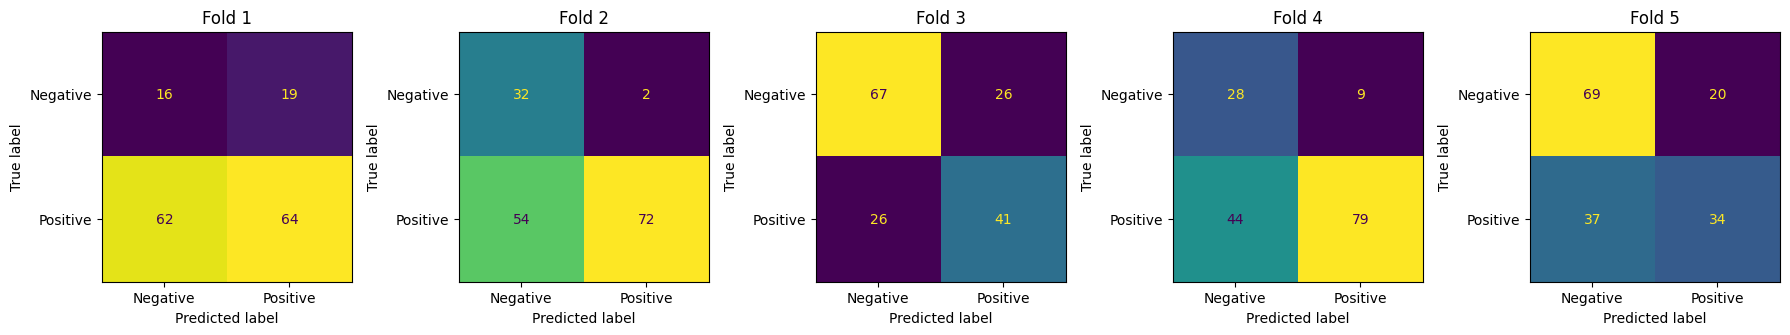

In [23]:
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

fig, axes = plt.subplots(1, 5, figsize=(18, 4))

for i, cm in enumerate(confusion_matrices):
    disp = ConfusionMatrixDisplay(
        confusion_matrix=cm,
        display_labels=["Negative", "Positive"]
    )
    disp.plot(ax=axes[i], colorbar=False)
    axes[i].set_title(f"Fold {i+1}")

plt.tight_layout()
plt.savefig("./saved_models/baseline_confusion_matrices_5fold.png", dpi=300, bbox_inches="tight")
plt.show()